# Week 1 - Introduction to Data Analysis

**Paññāsāstra University of Cambodia**
**Course:** Data Analysis and Visualization (3 credits)
**Chapter 1 - Introduction to Data Analysis**

---

## Session topics (from the course outline)

- What is data analysis?
- Types of data: structured versus unstructured
- The role of data visualization
- Tools for data analysis

## Course learning outcomes addressed

| CLO | Statement |
|---|---|
| **CLO 1** | Explain the fundamental concepts of data analysis and visualization |
| **CLO 2** | Identify suitable tools and techniques for analyzing different types of datasets |
| **CLO 3** | Apply Python libraries (NumPy, Pandas) to clean, manipulate, and process datasets |
| **CLO 5** | Perform exploratory data analysis (EDA) to summarize and interpret datasets |

## Reading

| Topic | Source |
|---|---|
| What kinds of data; why Python | McKinney, *Python for Data Analysis* (3rd ed.), §1.1–1.2 |
| Essential Python libraries | McKinney, §1.3 |
| Summary statistics in pandas | McKinney, §5.3 |
| Choosing the right chart | Pfaffelhuber, *Python for Data Analysis*, §8.1 |
| Descriptive statistics | Pfaffelhuber, §9.1 |

## Structure of this notebook

| Part | Content | Setting |
|---|---|---|
| **1** | Theory and concepts | Lecture |
| **2** | Instructor code example | Lecture, live execution |
| **3** | Guided workshop | In class, you complete the `TODO`s |
| **4** | Homework | After class, validated by `assert` |

---

## Setup

All imports for this notebook are defined in the single cell below. Run it first. If any
import fails, return to Notebook 00 and check your environment.

In [1]:
# ---------------------------------------------------------------------------
# All imports for this notebook. Run this cell first.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Reproducibility: every random dataset in this notebook is generated from this
# seed, so your numbers will match the ones shown in the lecture exactly.
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Consistent, colour-blind-safe plotting defaults for the whole course.
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 100,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
})
sns.set_palette(PALETTE)

# Show more columns when printing DataFrames.
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Environment ready.")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  seaborn    {sns.__version__}")
print(f"  random seed {RANDOM_SEED}")

Environment ready.
  numpy      2.5.3
  pandas     3.0.6
  seaborn    0.13.2
  random seed 42


---

# Part 1 - Theory and concepts

## 1.1 What data analysis is

Data analysis is the process of turning recorded observations into statements that a
decision-maker can act on. McKinney (§1.1) describes the subject of his book as "the nuts
and bolts of manipulating, processing, cleaning, and crunching data in Python", and notes
that much of the work is more accurately called **data manipulation**, or **wrangling**
or **munging**, than analysis proper.

That emphasis is deliberate and worth taking seriously at the start of the course. In
practical work, the analytical step computing a mean, fitting a line, drawing a chart
is short. The preparation that makes it valid is long.

A working analysis proceeds through six stages:

| Stage | Question it answers | Weeks in this course |
|---|---|---|
| **1. Question** | What decision depends on the answer? | 1 |
| **2. Collection** | Where does the data come from, and what does it actually measure? | 1, 4 |
| **3. Cleaning** | Which values are missing, duplicated, or impossible? | 5 |
| **4. Exploration** | What is the shape, spread and structure of the data? | 6, 9 |
| **5. Modelling** | What relationships hold, and how confident can we be? | 12 |
| **6. Communication** | What should the audience understand and do? | 7, 8, 11, 13 |

The stages are not strictly sequential. Exploration routinely reveals a cleaning problem;
cleaning routinely reveals that the collected data cannot answer the original question.
Iteration is normal, and the ordering above describes dependency, not chronology.

**The first stage is the one most often skipped.** An analysis without a question produces
charts that are correct and useless. Before writing any code, state the question in a
single sentence, and state what a useful answer would look like.

## 1.2 What counts as data

McKinney (§1.1) defines the primary focus as **structured data**, described as a
deliberately vague term covering:

- Tabular or spreadsheet-like data, in which each column may hold a different type
  (string, numeric, date). This includes most data held in relational databases or in
  delimited text files.
- Multidimensional arrays, that is, matrices.
- Multiple tables interrelated by key columns -gf primary and foreign keys, in database
  terms.
- Evenly or unevenly spaced time series.

He adds an important qualification: a large percentage of datasets can be *transformed*
into a structured form suitable for analysis. A collection of news articles is not
tabular, but it can be processed into a word-frequency table, which is. Part 2 of this
notebook demonstrates exactly that transformation.

### Three categories of data

| Category | Definition | Examples | Typical storage |
|---|---|---|---|
| **Structured** | Fixed schema; every record has the same fields in the same order | Sales transactions, sensor readings, student records | Relational database, CSV, Excel |
| **Semi-structured** | Self-describing, with tags or keys, but no fixed schema across records | JSON API responses, XML documents, log files | Document store, JSON files |
| **Unstructured** | No predefined organisation | Free-text reviews, images, audio, video | File system, object store |

The categories describe *storage form*, not *value*. The practical consequence is a
difference in the amount of work required before analysis can begin: structured data is
ready for a `DataFrame` immediately, semi-structured data requires parsing and
flattening, and unstructured data requires a **feature extraction** step that produces
structure where none existed.

## 1.3 Levels of measurement

Knowing that a column holds numbers is not enough to know what may be done with it. A
postal code and a temperature are both stored as integers, but only one of them has a
meaningful mean. The standard classification, due to Stevens (1946), distinguishes four
levels.

| Level | Distinguishes | Ordered | Equal intervals | True zero | Valid operations | Example |
|---|---|:---:|:---:|:---:|---|---|
| **Nominal** | Category only | no | no | no | counts, mode | Payment method, student ID |
| **Ordinal** | Rank order | yes | no | no | median, quantiles | Satisfaction rating 1–5 |
| **Interval** | Differences | yes | yes | no | mean, difference | Temperature in °C, calendar date |
| **Ratio** | Ratios | yes | yes | yes | all arithmetic, CV | Price, quantity, weight |

Two consequences matter throughout the course:

1. **The mean of an ordinal variable is not well defined.** A satisfaction scale of 1–5
   does not guarantee that the distance from 1 to 2 equals the distance from 4 to 5.
   A reported mean rating of 3.7 is common in practice and should be read as a convenient
   summary, not as a measurement. The median is the defensible statistic.
2. **Ratios require a true zero.** 20 °C is not twice as warm as 10 °C, because 0 °C is a
   convention rather than an absence of temperature. A price of \$20 *is* twice \$10.

## 1.4 Tidy data

Before a dataset can be analysed conveniently it should be *tidy*, in the sense set out by
Wickham (2014):

1. Each **variable** forms a column.
2. Each **observation** forms a row.
3. Each **type of observational unit** forms a table.

The following table is untidy, because `Q1`, `Q2`, `Q3` are values of a variable
(quarter), not variables in their own right:

| region | Q1 | Q2 | Q3 |
|---|---|---|---|
| North | 120 | 135 | 150 |
| South | 98 | 102 | 110 |

Its tidy form has one row per observation:

| region | quarter | sales |
|---|---|---|
| North | Q1 | 120 |
| North | Q2 | 135 |
| North | Q3 | 150 |
| South | Q1 | 98 |
| ... | ... | ... |

The tidy form is longer and less readable on a page, which is why reports are usually
published in the wide form. It is also the form that grouping, aggregation and most
plotting functions expect. Converting between the two is covered in Week 6.

## 1.5 Descriptive statistics

A small set of summary statistics describes most of what a numeric variable does. Let
$x_1, x_2, \dots, x_n$ be $n$ observations.

**Centre.** The arithmetic mean is

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

The median is the value at the 50th percentile: the middle observation of the sorted data
when $n$ is odd, and the mean of the two middle observations when $n$ is even. The mean
uses every value and is therefore sensitive to extreme ones; the median uses only the
ordering and is not.

**Spread.** The sample variance and standard deviation are

$$s^{2} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^{2}
\qquad\qquad
s = \sqrt{s^{2}}$$

The divisor $n-1$ rather than $n$ is **Bessel's correction**. Because the deviations are
measured from $\bar{x}$, which was itself estimated from the same data, dividing by $n$
underestimates the population variance; $n-1$ corrects this bias. The distinction has a
direct practical consequence in Python:

- `pandas` uses $n-1$ by default (`ddof=1`).
- `numpy` uses $n$ by default (`ddof=0`).

The two therefore return different numbers for the same data. Part 2 demonstrates this
explicitly, because it is a common source of confusion when results are compared across
tools.

The interquartile range is the spread of the middle half of the data,

$$\mathrm{IQR} = Q_3 - Q_1$$

where $Q_1$ and $Q_3$ are the 25th and 75th percentiles. Like the median, it is
insensitive to extreme values.

**Association.** The Pearson correlation coefficient between two variables is

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^{2}}\;\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^{2}}}$$

with $-1 \le r_{xy} \le 1$. It measures the strength of the **linear** association only.
A value near zero rules out a linear relationship; it does not rule out a relationship.

## 1.6 The role of data visualization

Summary statistics compress a dataset to a few numbers, and compression discards
information. The question is whether what was discarded mattered.

Anscombe (1973) constructed four datasets, each of eleven $(x, y)$ pairs, that are
effectively identical under every statistic listed above: the same mean of $x$, the same
mean of $y$, the same variances, the same correlation of approximately 0.816, and the
same fitted regression line $\hat{y} = 3.00 + 0.500x$. Plotted, they are obviously and
completely different. One is an ordinary linear relationship, one is a clean curve, one is
a perfect line disturbed by a single outlier, and one has no variation in $x$ at all
except for a single leverage point.

Part 2 reproduces this result. The conclusion to take from it is procedural rather than
decorative: **plot the data before summarising it, and plot the residuals after modelling
it.** Visualization in this course is not presentation varnish applied at the end. It is
an inspection instrument used throughout.

Visualization serves two distinct purposes, and confusing them produces poor charts:

| Purpose | Audience | Priorities |
|---|---|---|
| **Exploratory** | The analyst | Speed, quantity, no styling; many rough charts |
| **Explanatory** | The decision-maker | Clarity, one message per chart, careful labelling |

### Choosing the chart

Pfaffelhuber (§8.1) frames the choice by the question being asked, not by the chart's
appearance.

| Question | Chart | Week |
|---|---|---|
| How is one numeric variable distributed? | Histogram, density plot, box plot | 7, 8 |
| How do categories compare on one measure? | Bar chart | 7 |
| How do two numeric variables relate? | Scatter plot | 7 |
| How does a value change over time? | Line chart | 10 |
| How do many variables relate at once? | Pair plot, heatmap | 8 |
| What share does each part hold of a whole? | Stacked bar (pie only for very few categories) | 7 |

## 1.7 The tools

McKinney (§1.3) describes the ecosystem this course uses. The division of responsibility
is worth learning early, because it tells you which library's documentation to open.

| Library | Core abstraction | Responsibility |
|---|---|---|
| **NumPy** | `ndarray` | Homogeneous n-dimensional numeric arrays; vectorised arithmetic; the memory layout that everything else is built on |
| **pandas** | `Series`, `DataFrame` | Labelled, heterogeneous tabular data; automatic alignment; missing data; joins; time series |
| **matplotlib** | `Figure`, `Axes` | The plotting engine; complete control of every visual element |
| **seaborn** | plotting functions | Statistical graphics over matplotlib; concise syntax for distributions and categories |
| **SciPy** | `scipy.stats` and others | Distributions, statistical tests, optimisation, integration |
| **Plotly** | `Figure` | Interactive, browser-rendered charts and dashboards |

pandas is built on NumPy, and seaborn is built on matplotlib and pandas. A `DataFrame`
column is, underneath, a NumPy array, which is why NumPy is taught first (Week 3) even
though pandas is what you will use most.

### Why Python

McKinney (§1.2) makes the argument in terms of the **two-language problem**. Organisations
have historically prototyped in one language (R, SAS, MATLAB) and then rewritten the
result in another for production (Java, C++). Python is capable enough in both roles that
the rewrite can be avoided, which removes an entire category of translation error and
organisational friction.

---

---

# Part 2 - Instructor code example

The code below is complete and executable. It is intended to be run cell by cell during
the lecture. Three things are demonstrated:

1. Building and classifying a structured dataset.
2. Computing descriptive statistics by hand and verifying them against pandas.
3. Reproducing Anscombe's quartet, to establish why visualization is necessary.

A fourth section shows the transformation of unstructured text into structured counts.

## 2.1 Building a structured dataset

Rather than downloading a file, this notebook generates its dataset from a fixed random
seed. Every student therefore obtains identical numbers, and no cell depends on network
access.

The scenario is a university café recording one row per transaction.

In [3]:
def generate_cafe_transactions(n_rows: int = 500, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Generate a reproducible synthetic café transactions dataset.

    Each row is one transaction. The columns deliberately span all four levels
    of measurement so that they can be classified in section 2.2.

    Parameters
    ----------
    n_rows : int
        Number of transactions to generate.
    seed : int
        Seed for the random number generator, ensuring reproducibility.

    Returns
    -------
    pandas.DataFrame
        The generated dataset, with n_rows rows.
    """
    generator = np.random.default_rng(seed)

    menu = {
        # item          category      base price (USD)
        "Iced Coffee":  ("Beverage",  2.25),
        "Hot Latte":    ("Beverage",  2.75),
        "Fruit Shake":  ("Beverage",  2.50),
        "Bottled Water": ("Beverage", 0.75),
        "Num Pang":     ("Food",      2.00),
        "Fried Rice":   ("Food",      3.50),
        "Croissant":    ("Bakery",    1.50),
        "Banana Cake":  ("Bakery",    1.25),
    }
    items = list(menu.keys())
    # Beverages sell more often than food, food more often than bakery.
    item_weights = np.array([0.20, 0.15, 0.12, 0.08, 0.15, 0.12, 0.10, 0.08])

    chosen_items = generator.choice(items, size=n_rows, p=item_weights)
    categories = [menu[item][0] for item in chosen_items]
    unit_prices = np.array([menu[item][1] for item in chosen_items])

    # Transaction dates across one academic month, weekdays busier than weekends.
    start = pd.Timestamp("2026-03-02")
    day_offsets = generator.integers(0, 28, size=n_rows)
    dates = start + pd.to_timedelta(day_offsets, unit="D")

    quantities = generator.choice([1, 1, 1, 2, 2, 3], size=n_rows)

    # Ratings correlate weakly with category: bakery scores slightly higher.
    rating_base = generator.normal(loc=4.0, scale=0.8, size=n_rows)
    rating_bonus = np.array([0.3 if c == "Bakery" else 0.0 for c in categories])
    ratings = np.clip(np.round(rating_base + rating_bonus), 1, 5).astype(int)

    frame = pd.DataFrame({
        "transaction_id": [f"TXN{100000 + i}" for i in range(n_rows)],
        "date": dates,
        "item": chosen_items,
        "category": categories,
        "quantity": quantities,
        "unit_price_usd": unit_prices,
        "customer_rating": ratings,
        "payment_method": generator.choice(
            ["Cash", "ABA Pay", "Wing", "Card"],
            size=n_rows,
            p=[0.35, 0.40, 0.15, 0.10],
        ),
        "is_member": generator.choice([True, False], size=n_rows, p=[0.3, 0.7]),
    })

    # Derived column: total value of the transaction.
    frame["total_usd"] = (frame["quantity"] * frame["unit_price_usd"]).round(2)
    frame["day_of_week"] = frame["date"].dt.day_name()

    return frame


cafe = generate_cafe_transactions()

print(f"Dataset shape: {cafe.shape[0]} rows x {cafe.shape[1]} columns\n")
print(cafe.head(8))

Dataset shape: 500 rows x 11 columns

  transaction_id       date         item  category  quantity  unit_price_usd  customer_rating payment_method  \
0      TXN100000 2026-03-24   Fried Rice      Food         2            3.50                3        ABA Pay   
1      TXN100001 2026-03-22  Fruit Shake  Beverage         1            2.50                5           Cash   
2      TXN100002 2026-03-17    Croissant    Bakery         1            1.50                4        ABA Pay   
3      TXN100003 2026-03-26     Num Pang      Food         1            2.00                4           Cash   
4      TXN100004 2026-03-05  Iced Coffee  Beverage         2            2.25                4           Cash   
5      TXN100005 2026-03-27  Banana Cake    Bakery         1            1.25                4        ABA Pay   
6      TXN100006 2026-03-25   Fried Rice      Food         3            3.50                4        ABA Pay   
7      TXN100007 2026-03-16   Fried Rice      Food         1      

In [4]:
# The three methods you will use on every new dataset for the rest of the course.
print("=" * 70)
print("STRUCTURE — .info() reports dtypes, non-null counts and memory use")
print("=" * 70)
cafe.info()

print("\n" + "=" * 70)
print("NUMERIC SUMMARY — .describe() reports count, mean, std and quartiles")
print("=" * 70)
print(cafe.describe().round(2))

print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY — .describe(include='object') reports cardinality")
print("=" * 70)
print(cafe.describe(include="object"))

STRUCTURE — .info() reports dtypes, non-null counts and memory use
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction_id   500 non-null    str           
 1   date             500 non-null    datetime64[us]
 2   item             500 non-null    str           
 3   category         500 non-null    str           
 4   quantity         500 non-null    int64         
 5   unit_price_usd   500 non-null    float64       
 6   customer_rating  500 non-null    int64         
 7   payment_method   500 non-null    str           
 8   is_member        500 non-null    bool          
 9   total_usd        500 non-null    float64       
 10  day_of_week      500 non-null    str           
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 39.7 KB

NUMERIC SUMMARY — .describe() reports count, mean, std and qua

C:\Users\63601\AppData\Local\Temp\ipykernel_4168\2147052160.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(cafe.describe(include="object"))


## 2.2 Classifying columns by level of measurement

`.info()` reports the *storage* type. It cannot report the *measurement* level, because
that is a fact about the world rather than about the bytes. `customer_rating` and
`quantity` are both stored as integers, but only `quantity` has a meaningful mean.

Classification is therefore a judgement the analyst supplies. The function below records
that judgement alongside the mechanical facts, and flags the statistics that would be
invalid.

In [5]:
# The analyst's judgement about what each column measures. This is domain
# knowledge, not something that can be inferred from the dtype.
MEASUREMENT_LEVELS = {
    "transaction_id":  "nominal",
    "date":            "interval",
    "item":            "nominal",
    "category":        "nominal",
    "quantity":        "ratio",
    "unit_price_usd":  "ratio",
    "customer_rating": "ordinal",
    "payment_method":  "nominal",
    "is_member":       "nominal",
    "total_usd":       "ratio",
    "day_of_week":     "ordinal",
}

# Which centre statistic is defensible at each level.
VALID_CENTRE = {
    "nominal":  "mode",
    "ordinal":  "median",
    "interval": "mean",
    "ratio":    "mean",
}


def classify_columns(frame: pd.DataFrame, levels: dict) -> pd.DataFrame:
    """Build a classification table for every column of a DataFrame.

    Parameters
    ----------
    frame : pandas.DataFrame
        The dataset to classify.
    levels : dict
        Maps column name -> measurement level, supplied by the analyst.

    Returns
    -------
    pandas.DataFrame
        One row per column, giving dtype, measurement level, number of unique
        values, missing count and the defensible centre statistic.
    """
    records = []
    for column in frame.columns:
        level = levels.get(column, "unspecified")
        records.append({
            "column": column,
            "dtype": str(frame[column].dtype),
            "level": level,
            "n_unique": frame[column].nunique(),
            "n_missing": int(frame[column].isna().sum()),
            "centre_statistic": VALID_CENTRE.get(level, "-"),
        })
    return pd.DataFrame(records)


classification = classify_columns(cafe, MEASUREMENT_LEVELS)
print(classification.to_string(index=False))

print("\nNote the two integer columns:")
print("  quantity        is ratio   -> a mean is meaningful")
print("  customer_rating is ordinal -> the median is the defensible statistic,")
print("                                even though pandas will happily compute a mean")

         column          dtype    level  n_unique  n_missing centre_statistic
 transaction_id            str  nominal       500          0             mode
           date datetime64[us] interval        28          0             mean
           item            str  nominal         8          0             mode
       category            str  nominal         3          0             mode
       quantity          int64    ratio         3          0             mean
 unit_price_usd        float64    ratio         8          0             mean
customer_rating          int64  ordinal         4          0           median
 payment_method            str  nominal         4          0             mode
      is_member           bool  nominal         2          0             mode
      total_usd        float64    ratio        20          0             mean
    day_of_week            str  ordinal         7          0           median

Note the two integer columns:
  quantity        is ratio   -> a

## 2.3 Descriptive statistics computed by hand and by pandas

The formulas in §1.5 are implemented directly below and then checked against pandas. Two
points are being established:

1. The library functions are not magic; each is a short formula.
2. The `ddof` difference between NumPy and pandas is real and must be controlled for.

In [6]:
def manual_summary(values: np.ndarray) -> dict:
    """Compute descriptive statistics from their definitions, without pandas.

    Implements the formulas from section 1.5 directly, so that the results can
    be compared against the library implementations.

    Parameters
    ----------
    values : numpy.ndarray
        A one-dimensional array of numeric observations.

    Returns
    -------
    dict
        Centre, spread and shape statistics.
    """
    x = np.asarray(values, dtype=float)
    n = x.size

    # Centre: mean is the sum divided by the count.
    mean = x.sum() / n

    # Centre: median is the middle of the sorted values.
    ordered = np.sort(x)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2

    # Spread: sample variance uses Bessel's correction, dividing by n - 1.
    squared_deviations = (x - mean) ** 2
    variance_sample = squared_deviations.sum() / (n - 1)
    variance_population = squared_deviations.sum() / n

    # Spread: interquartile range from the 25th and 75th percentiles.
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)

    return {
        "n": n,
        "mean": mean,
        "median": median,
        "variance_sample": variance_sample,
        "variance_population": variance_population,
        "std_sample": np.sqrt(variance_sample),
        "min": ordered[0],
        "q1": q1,
        "q3": q3,
        "max": ordered[-1],
        "iqr": q3 - q1,
        "range": ordered[-1] - ordered[0],
    }


totals = cafe["total_usd"].to_numpy()
manual = manual_summary(totals)

print("Descriptive statistics for 'total_usd', computed from the definitions")
print("-" * 62)
for name, value in manual.items():
    print(f"  {name:<22} {value:>10.4f}")

Descriptive statistics for 'total_usd', computed from the definitions
--------------------------------------------------------------
  n                        500.0000
  mean                       3.7025
  median                     2.7500
  variance_sample            4.7677
  variance_population        4.7581
  std_sample                 2.1835
  min                        0.7500
  q1                         2.2500
  q3                         5.0000
  max                       10.5000
  iqr                        2.7500
  range                      9.7500


In [7]:
# Verify the manual results against the library implementations.
series = cafe["total_usd"]

comparison = pd.DataFrame({
    "manual": [
        manual["mean"],
        manual["median"],
        manual["variance_sample"],
        manual["std_sample"],
        manual["q1"],
        manual["q3"],
        manual["iqr"],
    ],
    "pandas": [
        series.mean(),
        series.median(),
        series.var(),          # pandas default: ddof=1
        series.std(),          # pandas default: ddof=1
        series.quantile(0.25),
        series.quantile(0.75),
        series.quantile(0.75) - series.quantile(0.25),
    ],
}, index=["mean", "median", "variance", "std", "Q1", "Q3", "IQR"])

comparison["difference"] = comparison["manual"] - comparison["pandas"]
print(comparison.round(10))

# Confirm agreement to floating-point tolerance rather than by eye.
assert np.allclose(comparison["manual"], comparison["pandas"]), \
    "Manual and pandas results disagree"
print("\nAll manual results match pandas to floating-point tolerance.")

            manual    pandas  difference
mean      3.702500  3.702500         0.0
median    2.750000  2.750000         0.0
variance  4.767654  4.767654         0.0
std       2.183496  2.183496         0.0
Q1        2.250000  2.250000         0.0
Q3        5.000000  5.000000         0.0
IQR       2.750000  2.750000         0.0

All manual results match pandas to floating-point tolerance.


In [8]:
# The ddof trap: numpy and pandas disagree by default on the SAME data.
print("Variance of 'total_usd', computed four ways")
print("-" * 62)
print(f"  numpy  np.var(x)              = {np.var(totals):.6f}   (ddof=0, population)")
print(f"  numpy  np.var(x, ddof=1)      = {np.var(totals, ddof=1):.6f}   (ddof=1, sample)")
print(f"  pandas series.var()           = {series.var():.6f}   (ddof=1, sample)")
print(f"  pandas series.var(ddof=0)     = {series.var(ddof=0):.6f}   (ddof=0, population)")

print("\n  Default numpy and default pandas differ by:"
      f" {abs(np.var(totals) - series.var()):.6f}")
print("\n  The libraries are both correct; they have different defaults.")
print("  State ddof explicitly whenever a result will be compared across tools.")

# The difference shrinks as n grows, since (n-1)/n approaches 1.
print("\n  Relative difference by sample size, for the same underlying data:")
for n in [10, 50, 200, 1000]:
    sample = totals[:n] if n <= totals.size else totals
    pop, samp = np.var(sample), np.var(sample, ddof=1)
    print(f"    n = {sample.size:>4}   ratio sample/population = {samp / pop:.6f}")

Variance of 'total_usd', computed four ways
--------------------------------------------------------------
  numpy  np.var(x)              = 4.758119   (ddof=0, population)
  numpy  np.var(x, ddof=1)      = 4.767654   (ddof=1, sample)
  pandas series.var()           = 4.767654   (ddof=1, sample)
  pandas series.var(ddof=0)     = 4.758119   (ddof=0, population)

  Default numpy and default pandas differ by: 0.009535

  The libraries are both correct; they have different defaults.
  State ddof explicitly whenever a result will be compared across tools.

  Relative difference by sample size, for the same underlying data:
    n =   10   ratio sample/population = 1.111111
    n =   50   ratio sample/population = 1.020408
    n =  200   ratio sample/population = 1.005025
    n =  500   ratio sample/population = 1.002004


## 2.4 Why visualization is required: Anscombe's quartet

The four datasets below were constructed by Anscombe (1973). Their summary statistics are
computed first, before any chart is drawn.

In [9]:
def load_anscombe() -> pd.DataFrame:
    """Return Anscombe's quartet (1973) in tidy form.

    Returns
    -------
    pandas.DataFrame
        Columns: dataset ('I'–'IV'), x, y. 44 rows.
    """
    x_common = [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0]
    raw = {
        "I":   (x_common,
                [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
        "II":  (x_common,
                [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
        "III": (x_common,
                [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
        "IV":  ([8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 19.0, 8.0, 8.0, 8.0],
                [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
    }
    frames = [
        pd.DataFrame({"dataset": name, "x": xs, "y": ys})
        for name, (xs, ys) in raw.items()
    ]
    return pd.concat(frames, ignore_index=True)


def summarise_pair(group: pd.DataFrame) -> pd.Series:
    """Compute the summary statistics and fitted line for one (x, y) dataset."""
    x = group["x"].to_numpy()
    y = group["y"].to_numpy()
    # Least-squares straight line: returns [slope, intercept].
    slope, intercept = np.polyfit(x, y, deg=1)
    return pd.Series({
        "mean_x": x.mean(),
        "var_x": x.var(ddof=1),
        "mean_y": y.mean(),
        "var_y": y.var(ddof=1),
        "corr_xy": np.corrcoef(x, y)[0, 1],
        "slope": slope,
        "intercept": intercept,
    })


anscombe = load_anscombe()
stats_table = (
    anscombe.groupby("dataset")[["x", "y"]]
    .apply(summarise_pair)
    .round(3)
)

print("Summary statistics for the four datasets")
print("=" * 72)
print(stats_table.to_string())
print("=" * 72)
print("\nEvery column is effectively identical across all four datasets.")
print("On this evidence alone the four datasets are indistinguishable.")

Summary statistics for the four datasets
         mean_x  var_x  mean_y  var_y  corr_xy  slope  intercept
dataset                                                         
I           9.0   11.0   7.501  4.127    0.816    0.5      3.000
II          9.0   11.0   7.501  4.128    0.816    0.5      3.001
III         9.0   11.0   7.500  4.123    0.816    0.5      3.002
IV          9.0   11.0   7.501  4.123    0.817    0.5      3.002

Every column is effectively identical across all four datasets.
On this evidence alone the four datasets are indistinguishable.


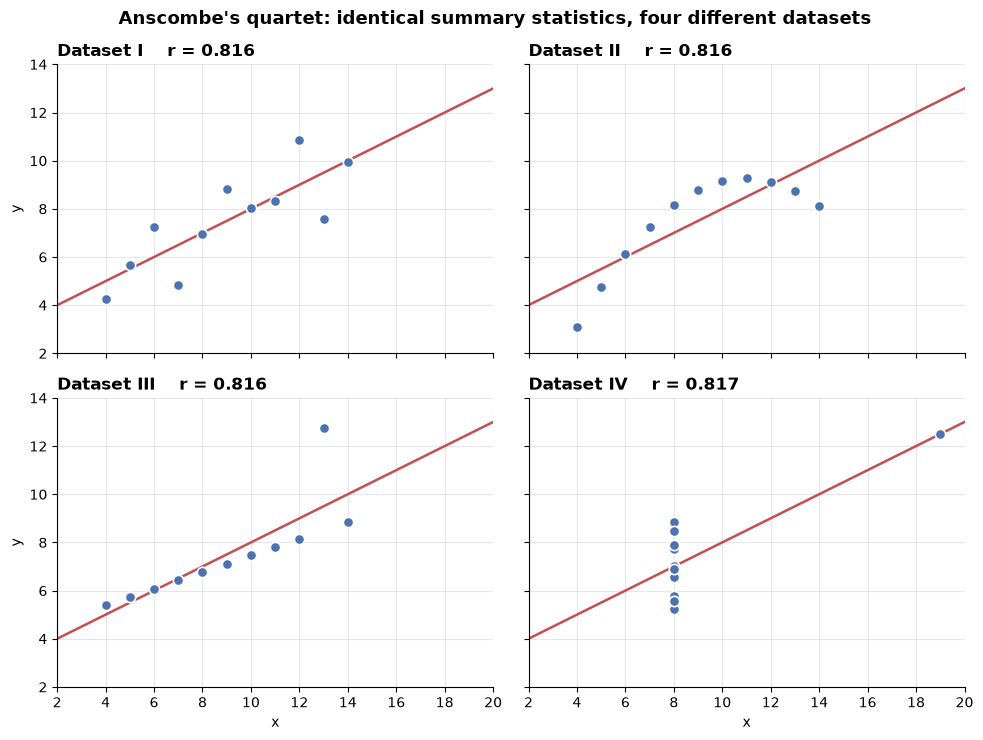

In [10]:
# Now plot the same four datasets.
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5), sharex=True, sharey=True)

fitted_line_x = np.array([2.0, 20.0])

for ax, (name, group) in zip(axes.flat, anscombe.groupby("dataset")):
    row = stats_table.loc[name]
    ax.scatter(group["x"], group["y"], s=55, color=PALETTE[0],
               edgecolor="white", linewidth=1.2, zorder=3)
    ax.plot(fitted_line_x, row["intercept"] + row["slope"] * fitted_line_x,
            color=PALETTE[3], linewidth=1.8, zorder=2)
    ax.set_title(f"Dataset {name}    r = {row['corr_xy']:.3f}", loc="left")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

for ax in axes[1, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")

fig.suptitle(
    "Anscombe's quartet: identical summary statistics, four different datasets",
    fontsize=13, fontweight="bold", y=0.98,
)
plt.tight_layout()
plt.show()

### What the four panels show

| Dataset | Structure | What the summary statistics conceal |
|---|---|---|
| **I** | An ordinary linear relationship with scatter | Nothing; here the summary is adequate |
| **II** | A clean quadratic curve | That the relationship is not linear at all |
| **III** | A perfect straight line plus one outlier | That ten of eleven points lie exactly on a line, and one does not |
| **IV** | No variation in $x$ except one leverage point | That the slope is determined entirely by a single observation |

In datasets II, III and IV the correlation of 0.816 and the fitted line
$\hat{y} = 3.00 + 0.500x$ are arithmetically correct and substantively misleading. No
additional statistic would have revealed the problem, because the datasets were
constructed to match on all of them. The chart reveals it immediately.

This is the argument for the workflow rule stated in §1.6: plot the data before
summarising it.

## 2.5 From unstructured text to a structured table

McKinney (§1.1) notes that unstructured data can often be transformed into a structured
form. The cell below performs that transformation on free-text customer feedback,
producing a word-frequency table that can then be analysed and plotted like any other
tabular dataset.

In [11]:
# Unstructured input: free text, no schema, variable length.
FEEDBACK = [
    "The iced coffee was excellent and the service was fast",
    "Service was slow today but the coffee was good",
    "Excellent food and excellent coffee, very good value",
    "The croissant was stale and the service was slow",
    "Fast service, good coffee, will come back",
    "Coffee was cold and the service was slow again",
    "Very good fruit shake and fast friendly service",
    "Good value for money, the fried rice was excellent",
]

# Words carrying no topical information are removed before counting.
STOP_WORDS = {
    "the", "was", "and", "a", "an", "for", "but", "very", "will", "be",
    "is", "it", "to", "of", "in", "on", "today", "again", "back", "come",
}


def text_to_frequency_table(documents: list, stop_words: set, top_n: int = 10) -> pd.DataFrame:
    """Convert a list of free-text documents into a word-frequency table.

    This is the feature-extraction step that gives unstructured data a
    structure suitable for analysis.

    Parameters
    ----------
    documents : list of str
        The raw text documents.
    stop_words : set
        Words to exclude from the count.
    top_n : int
        Number of most frequent words to return.

    Returns
    -------
    pandas.DataFrame
        Columns: word, frequency, share. Sorted by frequency, descending.
    """
    counter = Counter()
    for document in documents:
        # Normalise case and strip punctuation before splitting.
        cleaned = document.lower().replace(",", " ").replace(".", " ")
        words = [w for w in cleaned.split() if w and w not in stop_words]
        counter.update(words)

    total = sum(counter.values())
    rows = [
        {"word": word, "frequency": count, "share": count / total}
        for word, count in counter.most_common(top_n)
    ]
    return pd.DataFrame(rows)


frequencies = text_to_frequency_table(FEEDBACK, STOP_WORDS)

print("Input : 8 free-text documents (unstructured)")
print(f"Output: a {frequencies.shape[0]} x {frequencies.shape[1]} table (structured)\n")
print(frequencies.assign(share=lambda d: (d["share"] * 100).round(1)).to_string(index=False))
print("\nThe output is an ordinary DataFrame and can now be filtered, sorted,")
print("aggregated and plotted like any other structured dataset.")

Input : 8 free-text documents (unstructured)
Output: a 10 x 3 table (structured)

     word  frequency  share
  service          6   15.4
   coffee          5   12.8
     good          5   12.8
excellent          4   10.3
     fast          3    7.7
     slow          3    7.7
    value          2    5.1
     iced          1    2.6
     food          1    2.6
croissant          1    2.6

The output is an ordinary DataFrame and can now be filtered, sorted,
aggregated and plotted like any other structured dataset.


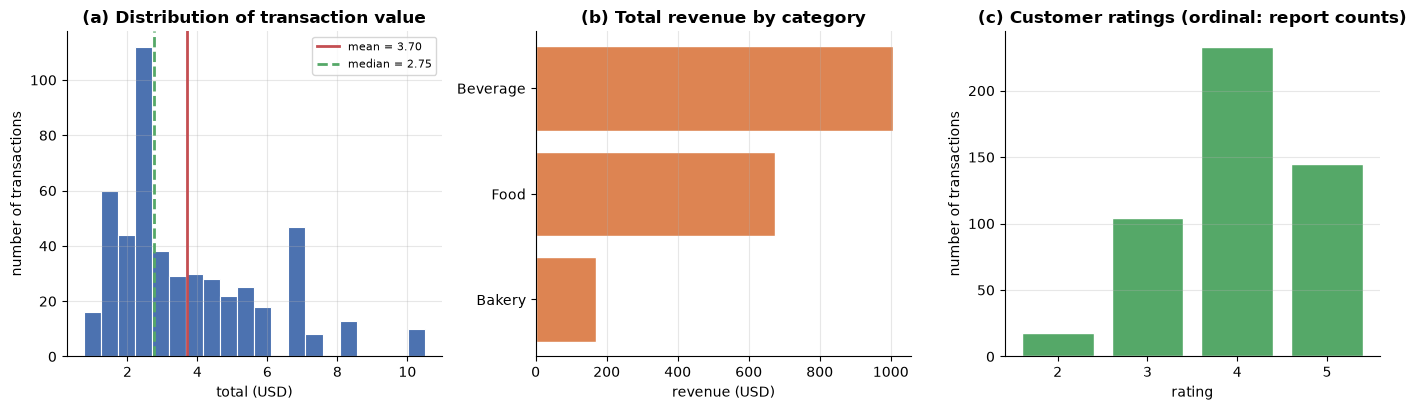

Median rating: 4.0   (the mean, 4.01, is reported often but is not strictly defensible for an ordinal scale)


In [12]:
# A first look at the café data, using three of the chart types from section 1.6.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) Distribution of one numeric variable -> histogram.
axes[0].hist(cafe["total_usd"], bins=20, color=PALETTE[0],
             edgecolor="white", linewidth=0.8)
axes[0].axvline(cafe["total_usd"].mean(), color=PALETTE[3], linewidth=2,
                label=f"mean = {cafe['total_usd'].mean():.2f}")
axes[0].axvline(cafe["total_usd"].median(), color=PALETTE[2], linewidth=2,
                linestyle="--", label=f"median = {cafe['total_usd'].median():.2f}")
axes[0].set_title("(a) Distribution of transaction value")
axes[0].set_xlabel("total (USD)")
axes[0].set_ylabel("number of transactions")
axes[0].legend(fontsize=8)

# (b) Comparison across categories -> bar chart.
revenue_by_category = cafe.groupby("category")["total_usd"].sum().sort_values()
axes[1].barh(revenue_by_category.index, revenue_by_category.to_numpy(),
             color=PALETTE[1], edgecolor="white")
axes[1].set_title("(b) Total revenue by category")
axes[1].set_xlabel("revenue (USD)")
axes[1].grid(axis="y", alpha=0)

# (c) Composition of an ordinal variable -> counts, not a mean.
rating_counts = cafe["customer_rating"].value_counts().sort_index()
axes[2].bar(rating_counts.index.astype(str), rating_counts.to_numpy(),
            color=PALETTE[2], edgecolor="white")
axes[2].set_title("(c) Customer ratings (ordinal: report counts)")
axes[2].set_xlabel("rating")
axes[2].set_ylabel("number of transactions")
axes[2].grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

print(f"Median rating: {cafe['customer_rating'].median():.1f}   "
      f"(the mean, {cafe['customer_rating'].mean():.2f}, is reported often "
      "but is not strictly defensible for an ordinal scale)")

---

# Part 3 - Guided workshop (in class)

You are given a synthetic dataset describing students enrolled in this course. Complete
the four tasks below by replacing each `TODO`. A verification cell follows each task; run
it to check your work before continuing.

Run the cell below first to generate the dataset. It is already complete.

In [13]:
def generate_student_survey(n_students: int = 120, seed: int = 7) -> pd.DataFrame:
    """Generate a reproducible synthetic student survey dataset.

    Returns
    -------
    pandas.DataFrame
        One row per student, with columns spanning all four measurement levels.
    """
    generator = np.random.default_rng(seed)

    year_levels = generator.choice(
        ["Year 1", "Year 2", "Year 3", "Year 4"], size=n_students,
        p=[0.30, 0.30, 0.25, 0.15],
    )
    # Study hours rise slightly with year level.
    year_index = np.array([int(y.split()[1]) for y in year_levels])
    study_hours = np.clip(
        generator.normal(loc=6 + year_index * 0.8, scale=2.5, size=n_students), 0, None
    ).round(1)

    # Exam score depends on study hours plus noise: a genuine linear relationship.
    exam_score = np.clip(
        42 + 3.6 * study_hours + generator.normal(0, 7.5, size=n_students), 0, 100
    ).round(1)

    frame = pd.DataFrame({
        "student_id": [f"S{2026000 + i}" for i in range(n_students)],
        "year_level": year_levels,
        "major": generator.choice(
            ["Computer Science", "Business", "Engineering", "Economics"],
            size=n_students, p=[0.35, 0.25, 0.25, 0.15],
        ),
        "study_hours_per_week": study_hours,
        "exam_score": exam_score,
        "confidence_rating": generator.integers(1, 6, size=n_students),
        "has_laptop": generator.choice([True, False], size=n_students, p=[0.82, 0.18]),
        "commute_minutes": generator.integers(5, 91, size=n_students),
    })
    return frame


survey = generate_student_survey()
print(f"Survey dataset: {survey.shape[0]} students, {survey.shape[1]} columns\n")
print(survey.head())
print("\nColumn dtypes:")
print(survey.dtypes)

Survey dataset: 120 students, 8 columns

  student_id year_level             major  study_hours_per_week  exam_score  confidence_rating  has_laptop  \
0   S2026000     Year 3          Business                   8.9        63.2                  5        True   
1   S2026001     Year 4       Engineering                   9.4        72.4                  2        True   
2   S2026002     Year 3         Economics                   6.9        72.4                  2        True   
3   S2026003     Year 1  Computer Science                   6.5        64.8                  3        True   
4   S2026004     Year 2  Computer Science                   2.6        52.0                  4        True   

   commute_minutes  
0               35  
1               68  
2               81  
3               84  
4               58  

Column dtypes:
student_id                  str
year_level                  str
major                       str
study_hours_per_week    float64
exam_score              floa

### Task 1 - Classify the columns

Assign each column its level of measurement.

**Problem.** Complete the `SURVEY_LEVELS` dictionary. Every column of `survey` must
appear exactly once, and each value must be one of `"nominal"`, `"ordinal"`,
`"interval"` or `"ratio"`.

**Hints**

- An identifier such as `student_id` labels but does not order: nominal.
- `year_level` has a meaningful order, but the gap between Year 1 and Year 2 is not
  guaranteed to equal the gap between Year 3 and Year 4.
- A `True`/`False` column is a two-category nominal variable.
- Ask of each numeric column: does zero mean "none of it"? If yes, it is ratio.

**Expected output.** A table of eight rows showing each column, its dtype and the level
you assigned, followed by `Task 1 complete`.

In [14]:
# TODO 1: complete this dictionary. One entry per column of `survey`.
#         Valid values: "nominal", "ordinal", "interval", "ratio"
SURVEY_LEVELS = {
    "student_id": "nominal",
    "year_level": "ordinal",
    # TODO: add the remaining six columns
    # "major": "nominal",
    # "study_hours_per_week": "ratio",
    # "exam_score": "ratio",
    # "confidence_rating": "ordinal",
    # "has_laptop": "nominal",
    # "commute_minutes": "ratio",
}

# Reuse the function written in Part 2.
survey_classification = classify_columns(survey, SURVEY_LEVELS)
print(survey_classification.to_string(index=False))

              column   dtype       level  n_unique  n_missing centre_statistic
          student_id     str     nominal       120          0             mode
          year_level     str     ordinal         4          0           median
               major     str unspecified         4          0                -
study_hours_per_week float64 unspecified        71          0                -
          exam_score float64 unspecified       103          0                -
   confidence_rating   int64 unspecified         5          0                -
          has_laptop    bool unspecified         2          0                -
     commute_minutes   int64 unspecified        68          0                -


In [15]:
# Verification for Task 1.
VALID_LEVELS = {"nominal", "ordinal", "interval", "ratio"}
EXPECTED = {
    "student_id", "year_level", "major", "study_hours_per_week",
    "exam_score", "confidence_rating", "has_laptop", "commute_minutes",
}

missing = EXPECTED - set(SURVEY_LEVELS)
extra = set(SURVEY_LEVELS) - EXPECTED
bad = {k: v for k, v in SURVEY_LEVELS.items() if v not in VALID_LEVELS}

if missing:
    print("Not complete. Missing columns:", sorted(missing))
elif extra:
    print("These keys are not columns of `survey`:", sorted(extra))
elif bad:
    print("These entries use an invalid level:", bad)
else:
    # Check the judgements that have a defensible single answer.
    checks = {
        "confidence_rating": "ordinal",
        "study_hours_per_week": "ratio",
        "exam_score": "ratio",
        "commute_minutes": "ratio",
        "major": "nominal",
        "has_laptop": "nominal",
    }
    wrong = {k: SURVEY_LEVELS[k] for k, v in checks.items() if SURVEY_LEVELS[k] != v}
    if wrong:
        print("Reconsider these columns:", wrong)
        print("Hint: does zero mean 'none of it'? Is the spacing between values equal?")
    else:
        print("Task 1 complete. All eight columns classified correctly.")

Not complete. Missing columns: ['commute_minutes', 'confidence_rating', 'exam_score', 'has_laptop', 'major', 'study_hours_per_week']


### Task 2 - Summarise a numeric variable

**Problem.** Complete `summarise_column` so that it returns a dictionary of descriptive
statistics for one numeric column, using pandas methods.

**Hints**

- `series.mean()`, `series.median()`, `series.std()`, `series.min()`, `series.max()`.
- Quartiles come from `series.quantile(0.25)` and `series.quantile(0.75)`.
- The IQR is the difference between the two quartiles.
- Keep `std` at the pandas default, `ddof=1`.

**Expected output.** Statistics printed for `exam_score` and `study_hours_per_week`,
followed by `Task 2 complete`.

In [16]:
def summarise_column(frame: pd.DataFrame, column: str) -> dict:
    """Return descriptive statistics for one numeric column.

    Parameters
    ----------
    frame : pandas.DataFrame
        The dataset.
    column : str
        Name of a numeric column in `frame`.

    Returns
    -------
    dict
        Keys: 'n', 'mean', 'median', 'std', 'min', 'q1', 'q3', 'max', 'iqr'.
    """
    series = frame[column]

    # TODO 2: build and return the dictionary described above.
    #         'n' should be the number of non-missing values: use series.count().
    # q1 = series.quantile(0.25)
    # q3 = series.quantile(0.75)
    # return {
    #     "n": series.count(),
    #     "mean": series.mean(),
    #     "median": series.median(),
    #     "std": series.std(),
    #     "min": series.min(),
    #     "q1": q1,
    #     "q3": q3,
    #     "max": series.max(),
    #     "iqr": q3 - q1,
    # }

    raise NotImplementedError("Complete TODO 2")


for column in ["exam_score", "study_hours_per_week"]:
    print(f"\n{column}")
    print("-" * len(column))
    for name, value in summarise_column(survey, column).items():
        print(f"  {name:<8} {value:>8.2f}")


exam_score
----------


NotImplementedError: Complete TODO 2

In [ ]:
# Verification for Task 2.
try:
    result = summarise_column(survey, "exam_score")
except NotImplementedError:
    print("Not complete: TODO 2 still raises NotImplementedError.")
else:
    expected_keys = {"n", "mean", "median", "std", "min", "q1", "q3", "max", "iqr"}
    if set(result.keys()) != expected_keys:
        print("Wrong keys. Expected:", sorted(expected_keys))
        print("Got:              ", sorted(result.keys()))
    else:
        series = survey["exam_score"]
        problems = []
        if not np.isclose(result["mean"], series.mean()):
            problems.append("mean")
        if not np.isclose(result["median"], series.median()):
            problems.append("median")
        if not np.isclose(result["std"], series.std()):
            problems.append("std (use the pandas default, ddof=1)")
        if not np.isclose(result["iqr"], series.quantile(0.75) - series.quantile(0.25)):
            problems.append("iqr")
        if result["n"] != series.count():
            problems.append("n")
        if problems:
            print("Check these values:", ", ".join(problems))
        else:
            print("Task 2 complete. All statistics correct.")

### Task 3 - Compare a group difference

**Problem.** Compute the mean exam score for each `year_level`, sorted from Year 1 to
Year 4, and store it in `score_by_year` as a pandas `Series` indexed by year level.

**Hints**

- `frame.groupby("column")["other_column"].mean()` produces exactly this.
- `groupby` sorts its index alphabetically by default, which for `"Year 1"` … `"Year 4"`
  happens to give the correct order.

**Expected output.** Four rows, one per year level, followed by `Task 3 complete`.

In [ ]:
# TODO 3: compute the mean exam_score for each year_level.
#         Assign the resulting Series to `score_by_year`.
score_by_year = None  # replace this line
# score_by_year = survey.groupby("year_level")["exam_score"].mean()

print(score_by_year)

In [ ]:
# Verification for Task 3.
if score_by_year is None:
    print("Not complete: `score_by_year` is still None.")
elif not isinstance(score_by_year, pd.Series):
    print(f"Expected a pandas Series, got {type(score_by_year).__name__}.")
else:
    reference = survey.groupby("year_level")["exam_score"].mean()
    if len(score_by_year) != 4:
        print(f"Expected 4 groups, got {len(score_by_year)}.")
    elif not np.allclose(score_by_year.sort_index().to_numpy(),
                         reference.sort_index().to_numpy()):
        print("The values do not match the expected group means.")
    else:
        print("Task 3 complete.")
        spread = score_by_year.max() - score_by_year.min()
        print(f"\nSpread between highest and lowest year group: {spread:.1f} marks")

### Task 4 - Plot before you conclude

**Problem.** Produce a figure with two panels:

- **Left:** a scatter plot of `study_hours_per_week` (x) against `exam_score` (y).
- **Right:** a histogram of `exam_score` with 15 bins.

Label both axes on both panels and give each a title.

**Hints**

- `fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))` gives two panels side by side.
- `axes[0].scatter(x, y, alpha=0.6, color=PALETTE[0])`.
- `axes[1].hist(values, bins=15, color=PALETTE[1], edgecolor="white")`.
- Set labels with `ax.set_xlabel(...)`, `ax.set_ylabel(...)`, `ax.set_title(...)`.
- Finish with `plt.tight_layout()` and `plt.show()`.

**Expected output.** A two-panel figure. The scatter should show a clear upward trend,
consistent with the correlation printed beneath it.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# TODO 4a: draw the scatter plot on axes[0], with axis labels and a title.
# axes[0].scatter(survey["study_hours_per_week"], survey["exam_score"],
#                 alpha=0.6, color=PALETTE[0], edgecolor="white", linewidth=0.5)
# axes[0].set_xlabel("study hours per week")
# axes[0].set_ylabel("exam score")
# axes[0].set_title("Study hours against exam score")

# TODO 4b: draw the histogram of exam_score on axes[1], with labels and a title.
# axes[1].hist(survey["exam_score"], bins=15, color=PALETTE[1], edgecolor="white")
# axes[1].set_xlabel("exam score")
# axes[1].set_ylabel("number of students")
# axes[1].set_title("Distribution of exam scores")

plt.tight_layout()
plt.show()

# Once the figure is drawn, quantify what it shows.
correlation = survey["study_hours_per_week"].corr(survey["exam_score"])
print(f"Pearson correlation between study hours and exam score: r = {correlation:.3f}")
print("\nQuestion for discussion: does this correlation establish that studying")
print("more causes a higher score? What else could produce this pattern?")

In [ ]:
# Verification for Task 4.
axis0, axis1 = axes[0], axes[1]

problems = []
if len(axis0.collections) == 0:
    problems.append("no scatter plot found on the left panel")
if len(axis1.patches) == 0:
    problems.append("no histogram found on the right panel")
for i, ax in enumerate([axis0, axis1]):
    side = "left" if i == 0 else "right"
    if not ax.get_xlabel():
        problems.append(f"{side} panel has no x-axis label")
    if not ax.get_ylabel():
        problems.append(f"{side} panel has no y-axis label")
    if not ax.get_title():
        problems.append(f"{side} panel has no title")

if problems:
    print("Not complete:")
    for problem in problems:
        print("  -", problem)
else:
    print("Task 4 complete. Both panels drawn and fully labelled.")

---

# Part 4 - Homework

Complete both problems before the Week 2 session.

Before submitting, use **Restart Kernel and Run All Cells** and confirm the notebook
completes without error. Commit and push the notebook to your `puc-data-analysis`
repository.

---

## Problem 1 - A reusable dataset profiler

Every dataset you meet for the rest of this course needs the same first inspection. Write
it once, here, and reuse it.

**Problem.** Write `profile_dataset(frame)`, returning a dictionary that summarises any
`DataFrame`.

**Requirements.** The returned dictionary must contain exactly these keys:

| Key | Type | Value |
|---|---|---|
| `n_rows` | `int` | Number of rows |
| `n_columns` | `int` | Number of columns |
| `numeric_columns` | `list` | Names of numeric columns, in the order they appear in the frame |
| `non_numeric_columns` | `list` | All other column names, in the order they appear |
| `missing_total` | `int` | Total count of missing values across the whole frame |
| `missing_by_column` | `dict` | Maps column name -> missing count, **only** for columns with at least one missing value |
| `duplicate_rows` | `int` | Number of fully duplicated rows |
| `memory_kb` | `float` | Approximate memory use in kilobytes, rounded to 2 decimal places |

**Hints**

- `frame.shape` returns `(n_rows, n_columns)`.
- `frame.select_dtypes(include="number").columns` gives the numeric column names;
  wrap the result in `list(...)`. Note that pandas does **not** count a boolean column
  as numeric, so a `True`/`False` column belongs in `non_numeric_columns`.
- Build `non_numeric_columns` by iterating over `frame.columns` and keeping those absent
  from the numeric list. This preserves the original column order, which the tests check.
- `frame.isna().sum()` gives a `Series` of missing counts per column.
- `int(frame.duplicated().sum())` counts duplicated rows.
- `frame.memory_usage(deep=True).sum()` returns bytes; divide by 1024.
- Convert NumPy integers to Python `int` with `int(...)`, so the types are exactly as
  specified.

In [ ]:
# Problem 1 — starter code. Complete the function body.

def profile_dataset(frame: pd.DataFrame) -> dict:
    """Produce a structural profile of any DataFrame.

    Parameters
    ----------
    frame : pandas.DataFrame
        The dataset to profile.

    Returns
    -------
    dict
        Keys: 'n_rows', 'n_columns', 'numeric_columns', 'non_numeric_columns',
        'missing_total', 'missing_by_column', 'duplicate_rows', 'memory_kb'.
    """
    # TODO: build and return the dictionary described above.
    raise NotImplementedError("Complete profile_dataset()")


# Try it on the two datasets from this notebook.
for name, frame in [("cafe", cafe), ("survey", survey)]:
    profile = profile_dataset(frame)
    print(f"\n{name}: {profile['n_rows']} rows x {profile['n_columns']} columns")
    print(f"  numeric columns     : {profile['numeric_columns']}")
    print(f"  non-numeric columns : {profile['non_numeric_columns']}")
    print(f"  missing values      : {profile['missing_total']}")
    print(f"  duplicate rows      : {profile['duplicate_rows']}")
    print(f"  memory              : {profile['memory_kb']} KB")

In [ ]:
# Problem 1 — validation. All assertions must pass.

# A small frame with known, deliberately awkward properties.
test_frame = pd.DataFrame({
    "id":       [1, 2, 3, 4, 4],
    "name":     ["a", "b", None, "d", "d"],
    "value":    [10.0, np.nan, 30.0, 40.0, 40.0],
    "flag":     [True, False, True, False, False],
    "category": ["x", "y", "x", "z", "z"],
})

profile = profile_dataset(test_frame)

assert isinstance(profile, dict), "profile_dataset must return a dict"

expected_keys = {
    "n_rows", "n_columns", "numeric_columns", "non_numeric_columns",
    "missing_total", "missing_by_column", "duplicate_rows", "memory_kb",
}
assert set(profile.keys()) == expected_keys, (
    f"Expected exactly these keys: {sorted(expected_keys)}, got {sorted(profile.keys())}"
)

# Shape.
assert profile["n_rows"] == 5, f"n_rows should be 5, got {profile['n_rows']}"
assert profile["n_columns"] == 5, f"n_columns should be 5, got {profile['n_columns']}"
assert isinstance(profile["n_rows"], int), "n_rows must be a Python int"
assert isinstance(profile["n_columns"], int), "n_columns must be a Python int"

# Column typing. 'id' and 'value' are numeric; 'flag' is bool, which pandas
# also selects as numeric, so it belongs in numeric_columns.
assert isinstance(profile["numeric_columns"], list), "numeric_columns must be a list"
assert isinstance(profile["non_numeric_columns"], list), "non_numeric_columns must be a list"
assert set(profile["numeric_columns"]) == {"id", "value"}, (
    f"numeric_columns should be id, value. Note that pandas does NOT count a "
    f"boolean column as numeric. Got {profile['numeric_columns']}"
)
assert set(profile["non_numeric_columns"]) == {"name", "flag", "category"}, (
    f"non_numeric_columns should be name, flag, category; "
    f"got {profile['non_numeric_columns']}"
)
# Every column appears exactly once across the two lists.
assert (len(profile["numeric_columns"]) + len(profile["non_numeric_columns"])
        == profile["n_columns"]), "Every column must appear in exactly one of the two lists"
# Original column order is preserved.
assert profile["numeric_columns"] == ["id", "value"], (
    "numeric_columns must preserve the order the columns appear in the frame"
)
assert profile["non_numeric_columns"] == ["name", "flag", "category"], (
    "non_numeric_columns must preserve the order the columns appear in the frame"
)

# Missing values: one None in 'name', one NaN in 'value'.
assert profile["missing_total"] == 2, (
    f"missing_total should be 2, got {profile['missing_total']}"
)
assert isinstance(profile["missing_total"], int), "missing_total must be a Python int"
assert isinstance(profile["missing_by_column"], dict), "missing_by_column must be a dict"
assert profile["missing_by_column"] == {"name": 1, "value": 1}, (
    "missing_by_column must contain ONLY columns that have missing values; "
    f"got {profile['missing_by_column']}"
)

# Duplicates: row index 4 duplicates row index 3.
assert profile["duplicate_rows"] == 1, (
    f"duplicate_rows should be 1, got {profile['duplicate_rows']}"
)

# Memory.
assert isinstance(profile["memory_kb"], float), "memory_kb must be a float"
assert profile["memory_kb"] > 0, "memory_kb must be positive"
assert round(profile["memory_kb"], 2) == profile["memory_kb"], (
    "memory_kb must be rounded to 2 decimal places"
)

# A frame with no missing values and no duplicates.
clean = pd.DataFrame({"a": [1, 2, 3], "b": ["p", "q", "r"]})
clean_profile = profile_dataset(clean)
assert clean_profile["missing_total"] == 0
assert clean_profile["missing_by_column"] == {}, (
    "With no missing values, missing_by_column must be an empty dict"
)
assert clean_profile["duplicate_rows"] == 0
assert clean_profile["numeric_columns"] == ["a"]
assert clean_profile["non_numeric_columns"] == ["b"]

# It must work on the notebook's own datasets without error.
for frame in [cafe, survey]:
    result = profile_dataset(frame)
    assert result["n_rows"] == len(frame)
    assert result["n_columns"] == frame.shape[1]

print("Problem 1: all assertions passed.")

---

## Problem 2 - Five-number summary and outlier detection

The five-number summary is the basis of the box plot (Week 7) and of the outlier
detection you will perform in Week 9. Implement it here.

**Problem.** Write `five_number_summary(values)`, which returns the summary together with
Tukey's outlier fences.

**Definition.** Tukey's rule classifies an observation $x$ as an outlier when

$$x < Q_1 - 1.5 \times \mathrm{IQR} \qquad \text{or} \qquad x > Q_3 + 1.5 \times \mathrm{IQR}$$

**Requirements.** The returned dictionary must contain exactly these keys:

| Key | Type | Value |
|---|---|---|
| `min` | `float` | Smallest value |
| `q1` | `float` | 25th percentile |
| `median` | `float` | 50th percentile |
| `q3` | `float` | 75th percentile |
| `max` | `float` | Largest value |
| `iqr` | `float` | $Q_3 - Q_1$ |
| `lower_fence` | `float` | $Q_1 - 1.5 \times \mathrm{IQR}$ |
| `upper_fence` | `float` | $Q_3 + 1.5 \times \mathrm{IQR}$ |
| `outliers` | `list` | Values outside the fences, **sorted ascending** |
| `n_outliers` | `int` | Length of `outliers` |

**Requirements on input handling**

- Accept a list, a NumPy array or a pandas `Series`.
- Discard missing values (`NaN`) before computing anything.
- Raise `ValueError` with any message if, after discarding missing values, no observations
  remain.

**Hints**

- `np.asarray(values, dtype=float)` accepts all three input types.
- `x[~np.isnan(x)]` removes missing values.
- `np.percentile(x, 25)` and `np.percentile(x, 75)` give the quartiles; these use the same
  linear interpolation as `Series.quantile`, so the two agree.
- Build the outlier list with a boolean mask, then `np.sort(...)` and `.tolist()`.
- `float(...)` converts a NumPy scalar to a Python float.

In [ ]:
# Problem 2 — starter code. Complete the function body.

def five_number_summary(values) -> dict:
    """Compute the five-number summary and Tukey outlier fences.

    Parameters
    ----------
    values : list, numpy.ndarray or pandas.Series
        Numeric observations. Missing values are discarded.

    Returns
    -------
    dict
        Keys: 'min', 'q1', 'median', 'q3', 'max', 'iqr',
        'lower_fence', 'upper_fence', 'outliers', 'n_outliers'.

    Raises
    ------
    ValueError
        If no non-missing observations remain.
    """
    # TODO: implement as described above.
    raise NotImplementedError("Complete five_number_summary()")


# Apply it to the café transaction totals and the survey commute times.
for label, data in [
    ("cafe total_usd", cafe["total_usd"]),
    ("survey commute_minutes", survey["commute_minutes"]),
]:
    summary = five_number_summary(data)
    print(f"\n{label}")
    print("-" * len(label))
    print(f"  min {summary['min']:.2f} | Q1 {summary['q1']:.2f} | "
          f"median {summary['median']:.2f} | Q3 {summary['q3']:.2f} | "
          f"max {summary['max']:.2f}")
    print(f"  IQR {summary['iqr']:.2f}, fences "
          f"[{summary['lower_fence']:.2f}, {summary['upper_fence']:.2f}]")
    print(f"  outliers: {summary['n_outliers']}")

In [ ]:
# Problem 2 — validation. All assertions must pass.

# A dataset with one obvious high outlier.
# Sorted: 1,2,3,4,5,6,7,8,9,100
data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 100]
summary = five_number_summary(data)

assert isinstance(summary, dict), "five_number_summary must return a dict"

expected_keys = {
    "min", "q1", "median", "q3", "max", "iqr",
    "lower_fence", "upper_fence", "outliers", "n_outliers",
}
assert set(summary.keys()) == expected_keys, (
    f"Expected exactly these keys: {sorted(expected_keys)}, got {sorted(summary.keys())}"
)

# Values checked against numpy, which uses the same interpolation as pandas.
reference = np.asarray(data, dtype=float)
assert np.isclose(summary["min"], 1.0)
assert np.isclose(summary["max"], 100.0)
assert np.isclose(summary["median"], np.percentile(reference, 50))
assert np.isclose(summary["q1"], np.percentile(reference, 25))
assert np.isclose(summary["q3"], np.percentile(reference, 75))
assert np.isclose(summary["iqr"], summary["q3"] - summary["q1"])
assert np.isclose(summary["lower_fence"], summary["q1"] - 1.5 * summary["iqr"])
assert np.isclose(summary["upper_fence"], summary["q3"] + 1.5 * summary["iqr"])

# 100 lies far above the upper fence and must be flagged.
assert 100.0 in summary["outliers"], "100 must be detected as an outlier"
assert summary["n_outliers"] == len(summary["outliers"]), (
    "n_outliers must equal the length of the outliers list"
)
assert summary["outliers"] == sorted(summary["outliers"]), "outliers must be sorted ascending"
assert isinstance(summary["outliers"], list), "outliers must be a list, not an array"

# Types are Python scalars, not numpy scalars.
for key in ["min", "q1", "median", "q3", "max", "iqr", "lower_fence", "upper_fence"]:
    assert isinstance(summary[key], float), f"{key} must be a Python float"
assert isinstance(summary["n_outliers"], int), "n_outliers must be a Python int"

# Symmetric data with no outliers.
symmetric = five_number_summary([10, 20, 30, 40, 50])
assert symmetric["median"] == 30.0
assert symmetric["outliers"] == [], "Evenly spaced data should have no outliers"
assert symmetric["n_outliers"] == 0

# A low outlier must be detected as well as a high one.
both_sides = five_number_summary([-50, 1, 2, 3, 4, 5, 6, 7, 8, 60])
assert -50.0 in both_sides["outliers"], "A low outlier must be detected"
assert 60.0 in both_sides["outliers"], "A high outlier must be detected"
assert both_sides["outliers"] == sorted(both_sides["outliers"])

# Missing values are discarded, not propagated.
with_nan = five_number_summary([1, 2, np.nan, 3, 4, np.nan, 5])
no_nan = five_number_summary([1, 2, 3, 4, 5])
assert np.isclose(with_nan["median"], no_nan["median"]), (
    "NaN values must be discarded before computing the summary"
)
assert not np.isnan(with_nan["q1"]), "NaN must not propagate into the quartiles"
assert not np.isnan(with_nan["iqr"]), "NaN must not propagate into the IQR"

# All three input types are accepted and give the same answer.
as_list = five_number_summary([1, 2, 3, 4, 5])
as_array = five_number_summary(np.array([1, 2, 3, 4, 5]))
as_series = five_number_summary(pd.Series([1, 2, 3, 4, 5]))
assert as_list == as_array == as_series, (
    "list, ndarray and Series inputs must produce identical results"
)

# An empty input must raise ValueError, not return a dict of NaN.
for empty_input in [[], [np.nan, np.nan]]:
    try:
        five_number_summary(empty_input)
    except ValueError:
        pass
    else:
        raise AssertionError(
            f"five_number_summary({empty_input!r}) must raise ValueError"
        )

print("Problem 2: all assertions passed.")

---

## Written question

Answer in the Markdown cell below, in 150–250 words.

In Part 3 you computed a correlation of approximately 0.76 between study hours and exam
score in the survey dataset, and the scatter plot showed a clear upward trend.

1. State one explanation for this pattern other than "studying more raises the score".
2. Name one chart from §1.6 that would help you investigate your alternative explanation,
   and say what you would look for in it.
3. Referring to Anscombe's quartet, explain why reporting the correlation alone would be
   insufficient even if the causal interpretation were correct.

*Replace this text with your answer.*

**1.**

**2.**

**3.**

---

## Submission checklist

- [ ] All four workshop tasks print their `complete` message.
- [ ] Problem 1 prints `all assertions passed`.
- [ ] Problem 2 prints `all assertions passed`.
- [ ] The written question is answered in 150–250 words.
- [ ] **Restart Kernel and Run All Cells** completes with no errors.
- [ ] The notebook is committed and pushed to your `puc-data-analysis` repository.

## Looking ahead to Week 2

Week 2 revises the Python language features this course depends on — variables, control
flow, functions, and the built-in container types — and establishes the Jupyter workflow
in more detail. Before that session, read McKinney §2.3 and §3.1, and Pfaffelhuber §2–4.

---

## References

Anscombe, F. J. (1973). Graphs in statistical analysis. *The American Statistician*,
27(1), 17–21.

McKinney, W. (2022). *Python for Data Analysis: Data Wrangling with pandas, NumPy and
Jupyter* (3rd ed.). O'Reilly Media. §1.1–1.3, §5.3.

Pfaffelhuber, P. *Python for Data Analysis* (course notes). §8.1, §9.1.
Available at `https://pfaffelh.github.io/python_for_data/`.

Stevens, S. S. (1946). On the theory of scales of measurement. *Science*, 103(2684),
677–680.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10), 1–23.